# Basic Investment Model — Bayesian Phase 1 Validation

Validates the Bayesian estimation pipeline on the frictionless basic-investment
model, where the analytical policy is exact (`cost_convex == 0`,
`cost_fixed == 0`). Any inference error is therefore attributable to the
inference machinery itself, not to solver approximation.

Pipeline (matches `docs/paper/Bayesian.md` §2):

- **Filter**: Kalman (exact, via `tfp.distributions.LinearGaussianStateSpaceModel`).
- **Sampler**: NUTS (gradient-based, via `tfp.mcmc.NoUTurnSampler` with dual-averaging step-size adaptation).
- **DGP**: `BasicInvestmentEnv.simulate_smm_panel_data(mode="frictionless_analytical")` plus an
  iid Gaussian measurement-noise overlay on log-revenue (`η ~ N(0, σ_η²)`).
- **Validation**: single-run posterior recovery (§3) + an `R`-replicate coverage check (§4-5; Bayesian.md §2.8).

Three profiles below — `SMOKE` for quick sanity, `FULL` for a heavy single-run
demonstration paired with a small coverage check, `COVERAGE_CHECK` for the
full §2.8 procedure.  Compute is deterministic on CPU by default
(`USE_GPU = False`); flip to True for Colab GPU/TPU acceleration at the cost
of bit-identical reruns.

# Section 0: Setup

In [1]:
from pathlib import Path
import os
import sys
import time
import warnings
from dataclasses import asdict

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
warnings.filterwarnings('ignore', message=r'.*does not produce the same series as CPU implementation.*')
warnings.filterwarnings('ignore', message=r'.*casting an input of type complex64.*')

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# ----- Compute backend toggle ---------------------------------------------
# Default: CPU only.  TF stateless RNG is bit-identical across machines on
# CPU but not on Metal/GPU/TPU, which would violate the reproducibility
# claim in Bayesian.md §2.9.  Flip USE_GPU = True for Colab acceleration
# when you don't need bit-identical reruns.
USE_GPU = False

import tensorflow as tf
if not USE_GPU:
    tf.config.set_visible_devices([], 'GPU')
# Silence the LGSSM internal stationary-variance complex64→float32 warning
# (benign: real-only computation routed through a complex code path).
tf.get_logger().setLevel('ERROR')

import tensorflow_probability as tfp

print(f'tf: {tf.__version__}   tfp: {tfp.__version__}')
print(f'logical devices: {[d.device_type for d in tf.config.list_logical_devices()]}')

from src.v2.estimation import (
    BayesianCoverageConfig,
    BayesianRunConfig,
    run_coverage_check,
    run_mcmc,
)
from src.v2.estimation.bayesian_basic_investment import (
    bayesian_true_beta,
    make_bayesian_spec,
)
from src.v2.environments.basic_investment import (
    BasicInvestmentEnv,
    EconomicParams,
    ShockParams,
)
from src.v2.evaluation import prepare_evaluation_run, save_manifest_sections
from src.v2.utils.seeding import fold_in_seed

np.set_printoptions(precision=6, suppress=True)

/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


tf: 2.16.2   tfp: 0.24.0
logical devices: ['CPU']


# Section 1: Config

Three profiles:

- `SMOKE`: fast end-to-end smoke test (~3 min). Includes a tiny R=2 coverage check.
- `FULL`: single-run sanity at production spec for Section 3 figures (~12 min). No coverage check (running coverage at the FULL spec would multiply wall time by R with no statistical gain over `COVERAGE_CHECK` at the smaller per-rep spec).
- `COVERAGE_CHECK`: coverage validation at a smaller per-rep spec (~50 min, R=30). The Kalman + NUTS machinery is invariant in (N, T) above the identification threshold of the LGSSM, so the smaller per-rep spec preserves algorithm-level calibration at fewer seconds per replicate. See Bayesian.md §2.8 for the full design rationale.

Re-run `FULL` for paper figures; re-run `COVERAGE_CHECK` for the calibration table.

In [2]:
PROFILE = 'COVERAGE_CHECK'   # 'SMOKE' | 'FULL' | 'COVERAGE_CHECK'

# Profile design (per Bayesian.md §2.10):
#   SMOKE          gross sanity, fast end-to-end, R=2 coverage smoke.
#   FULL           single-run posterior figures at production spec; no
#                  coverage check (running coverage at this spec would
#                  multiply wall time by R with no statistical gain over
#                  COVERAGE_CHECK at the smaller per-rep spec).
#   COVERAGE_CHECK coverage validation at a smaller per-rep spec, R=30.
#                  The Kalman + NUTS machinery is invariant in (N, T)
#                  above the identification threshold, so calibration at
#                  the smaller spec implies calibration at FULL spec
#                  asymptotically. SBC at R>=100 (Talts et al. 2018) is
#                  the rigorous test, deferred to Future Extensions.
PROFILES = {
    'SMOKE': {
        'description': ('Quick smoke test: 2 chains × (200 warmup + 200 samples), '
                        'N=30 T=20 sanity; R=2 coverage at same spec. ~3 min total.'),
        'run_coverage':  True,
        'mcmc_sanity':   dict(n_chains=2, n_warmup=200, n_samples=200,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'mcmc_coverage': dict(n_chains=2, n_warmup=200, n_samples=200,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'sanity':   dict(n_firms=30, horizon=20, burn_in=20),
        'coverage': dict(n_replicates=2, n_firms=30, horizon=20, burn_in=20,
                         credible_level=0.95),
    },
    'FULL': {
        'description': ('Single-run sanity at production spec: 2 chains × '
                        '(600 warmup + 800 samples), N=80 T=30; ~12 min. '
                        'No coverage check (run COVERAGE_CHECK profile for §2.8).'),
        'run_coverage':  False,
        'mcmc_sanity':   dict(n_chains=4, n_warmup=600, n_samples=800,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'sanity':   dict(n_firms=80, horizon=30, burn_in=30),
    },
    'COVERAGE_CHECK': {
        'description': ('Coverage validation: R=30 reps × 2 chains × '
                        '(150 warmup + 200 samples), N=30 T=18 per rep. '
                        '~50 min on CPU. Smaller per-rep spec than FULL; '
                        'validates algorithm-level calibration (Kalman + NUTS '
                        'invariant in (N, T) above the identification threshold).'),
        'run_coverage':  True,
        'mcmc_sanity':   dict(n_chains=4, n_warmup=150, n_samples=200,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'mcmc_coverage': dict(n_chains=4, n_warmup=150, n_samples=200,
                              target_accept_prob=0.80, master_seed=(20, 26)),
        'sanity':   dict(n_firms=30, horizon=20, burn_in=15),
        'coverage': dict(n_replicates=30, n_firms=30, horizon=20, burn_in=15,
                         credible_level=0.95),
    },
}

assert PROFILE in PROFILES, f'Unknown profile: {PROFILE!r}'
PROFILE_CONFIG = PROFILES[PROFILE]
RUN_COVERAGE   = PROFILE_CONFIG.get('run_coverage', True)

# Ground truth: env's structural parameters plus an exogenous σ_η.
TRUE_ALPHA = 0.6
TRUE_RHO = 0.7
TRUE_SIG_EPS = 0.15
TRUE_SIG_ETA = 0.05

# Fixed (calibrated), not estimated.
INTEREST_RATE = 0.04
DEPRECIATION_RATE = 0.15

MCMC_SANITY  = BayesianRunConfig(**PROFILE_CONFIG['mcmc_sanity'])
SANITY_PANEL = PROFILE_CONFIG['sanity']
MCMC_COVERAGE = (BayesianRunConfig(**PROFILE_CONFIG['mcmc_coverage'])
                 if RUN_COVERAGE else None)
COV_CONFIG    = (BayesianCoverageConfig(**PROFILE_CONFIG['coverage'])
                 if RUN_COVERAGE else None)

# ----- Output directory for paper-grade tables and figures ---------------
# Per-profile subdir: FULL and COVERAGE_CHECK outputs co-exist without
# overwriting each other. Re-running the same profile overwrites only its
# own outputs (correct).
FIGURES_ROOT = (REPO_ROOT / 'outputs' / 'notebooks'
                / 'NB07_bayesian_validation' / PROFILE.lower())
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

SAVE_RUN = True
RUN_TAG  = f'bayesian-phase1-{PROFILE.lower()}'
EXPERIMENT_NAME = 'basic_investment_bayesian_validation'
RESULTS_ROOT    = str(REPO_ROOT / 'outputs' / 'notebooks')

RUN = prepare_evaluation_run(
    EXPERIMENT_NAME, save_run=SAVE_RUN, run_tag=RUN_TAG,
    results_root=RESULTS_ROOT,
)

print(f'Profile: {PROFILE}. {PROFILE_CONFIG["description"]}')
print(f'Run output : {RUN["run_dir"]}')
print(f'Figures dir: {FIGURES_ROOT}')
print()
print(f'Sanity MCMC:   n_chains={MCMC_SANITY.n_chains}, n_warmup={MCMC_SANITY.n_warmup}, '
      f'n_samples={MCMC_SANITY.n_samples}; panel N={SANITY_PANEL["n_firms"]}, T={SANITY_PANEL["horizon"]}')
if RUN_COVERAGE:
    print(f'Coverage MCMC: n_chains={MCMC_COVERAGE.n_chains}, n_warmup={MCMC_COVERAGE.n_warmup}, '
          f'n_samples={MCMC_COVERAGE.n_samples}; R={COV_CONFIG.n_replicates}, '
          f'panel N={COV_CONFIG.n_firms}, T={COV_CONFIG.horizon}')
else:
    print(f'Coverage check: DISABLED for {PROFILE} profile (run COVERAGE_CHECK for §2.8).')

Profile: COVERAGE_CHECK. Coverage validation: R=30 reps × 2 chains × (150 warmup + 200 samples), N=30 T=18 per rep. ~50 min on CPU. Smaller per-rep spec than FULL; validates algorithm-level calibration (Kalman + NUTS invariant in (N, T) above the identification threshold).
Run output : /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/basic_investment_bayesian_validation/bayesian-phase1-coverage_check
Figures dir: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/NB07_bayesian_validation/coverage_check

Sanity MCMC:   n_chains=4, n_warmup=150, n_samples=200; panel N=30, T=20
Coverage MCMC: n_chains=4, n_warmup=150, n_samples=200; R=30, panel N=30, T=20


# Section 2: Environment + Bayesian Spec

Build the frictionless env at the ground-truth structural parameters, then
build the `BayesianSpec`.  The spec carries: parameter names, prior
distribution, bijector, likelihood (Kalman closure), and a synthetic-panel
factory closed over the env.

Table saved to `paper/figures/bayesian-frictionless/prior_table.csv`.

In [3]:
econ = EconomicParams(
    interest_rate=INTEREST_RATE,
    depreciation_rate=DEPRECIATION_RATE,
    production_elasticity=TRUE_ALPHA,
    cost_convex=0.0,
    cost_fixed=0.0,
)
shocks = ShockParams(mu=0.0, rho=TRUE_RHO, sigma=TRUE_SIG_EPS)
env = BasicInvestmentEnv(econ_params=econ, shock_params=shocks)

spec = make_bayesian_spec(env)
beta_true = bayesian_true_beta(env, sigma_eta=TRUE_SIG_ETA)

prior_table = pd.DataFrame([
    {'parameter': 'alpha',         'true': beta_true['alpha'],         'prior': 'Beta(2, 2)',      'support': '(0, 1)',  'bijector': 'Sigmoid'},
    {'parameter': 'rho',           'true': beta_true['rho'],           'prior': 'Beta(2, 2)',      'support': '(0, 1)',  'bijector': 'Sigmoid'},
    {'parameter': 'sigma_epsilon', 'true': beta_true['sigma_epsilon'], 'prior': 'HalfNormal(0.3)', 'support': '(0, inf)', 'bijector': 'Exp'},
    {'parameter': 'sigma_eta',     'true': beta_true['sigma_eta'],     'prior': 'HalfNormal(0.1)', 'support': '(0, inf)', 'bijector': 'Exp'},
])
print(f'filter_kind: {spec.filter_kind.value}   sampler_kind: {spec.sampler_kind.value}')
print(f'observation_keys: {spec.observation_keys}')
display(prior_table)
prior_table.to_csv(FIGURES_ROOT / 'prior_table.csv', index=False)

_manifest_kwargs = dict(
    setup={'profile': PROFILE, 'description': PROFILE_CONFIG['description'],
           'use_gpu': USE_GPU},
    environment={'economic_params': asdict(econ), 'shock_params': asdict(shocks)},
    true_beta=beta_true,
    mcmc_sanity_config=asdict(MCMC_SANITY),
    sanity_panel=SANITY_PANEL,
)
if RUN_COVERAGE:
    _manifest_kwargs.update(
        mcmc_coverage_config=asdict(MCMC_COVERAGE),
        coverage_config=asdict(COV_CONFIG),
    )
save_manifest_sections(RUN, **_manifest_kwargs)

filter_kind: kalman   sampler_kind: nuts
observation_keys: ('y', 'log_k')


,parameter,true,prior,support,bijector
0,alpha,0.60,"Beta(2, 2)","(0, 1)",Sigmoid
1,rho,0.70,"Beta(2, 2)","(0, 1)",Sigmoid
2,sigma_epsilon,0.15,HalfNormal(0.3),"(0, inf)",Exp
3,sigma_eta,0.05,HalfNormal(0.1),"(0, inf)",Exp


PosixPath('/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/basic_investment_bayesian_validation/bayesian-phase1-coverage_check/manifest.json')

# Section 3: Single-Run Sanity Check

Synthesize one panel at `beta_true`, run NUTS on it, and inspect the posterior.
This section carries the bulk of the FULL profile's compute budget; numbers
here directly determine posterior precision.

- **Table 1**: posterior summary (median, 95% CI, R-hat, ESS) vs. truth.
- **Plot 1**: trace plots — visual chain mixing check.
- **Plot 2**: posterior marginal densities with true-value markers.

All saved under `paper/figures/bayesian-frictionless/`.

Seed plumbing follows §2.9: a single master pair derives all sub-seeds via
`fold_in_seed`.  Token-scoped folding means panel and MCMC draws are
independent.

In [4]:
SANITY_MASTER = MCMC_SANITY.master_seed
panel_seed = fold_in_seed(SANITY_MASTER, 'sanity', 'panel')
mcmc_seed  = fold_in_seed(SANITY_MASTER, 'sanity', 'mcmc')

panel = spec.synthesize_panel_fn(
    beta_true,
    n_firms=SANITY_PANEL['n_firms'],
    horizon=SANITY_PANEL['horizon'],
    burn_in=SANITY_PANEL['burn_in'],
    seed=panel_seed,
)
observed = {k: panel[k] for k in spec.observation_keys}
print(f'panel shapes: y={panel["y"].shape}, log_k={panel["log_k"].shape}')

t0 = time.perf_counter()
mcmc_result = run_mcmc(spec, observed, MCMC_SANITY, seed=mcmc_seed)
sanity_wall = time.perf_counter() - t0
print(f'MCMC wall time: {sanity_wall:.1f} s   acceptance: {mcmc_result.acceptance_rate:.3f}')

# Table 1
rows = []
for k in spec.parameter_names:
    s = mcmc_result.posterior_samples[k]
    rows.append({
        'parameter': k,
        'true':       beta_true[k],
        'median':     float(np.median(s)),
        'ci_low_2.5': float(np.quantile(s, 0.025)),
        'ci_hi_97.5': float(np.quantile(s, 0.975)),
        'r_hat':      mcmc_result.r_hat[k],
        'ess':        mcmc_result.ess[k],
    })
posterior_table = pd.DataFrame(rows)
print('Table 1. Posterior summary at beta_true (single-panel sanity check)')
display(posterior_table)
posterior_table.to_csv(FIGURES_ROOT / 'table1_posterior_summary.csv', index=False)

panel shapes: y=(30, 20, 1), log_k=(30, 20, 1)
MCMC wall time: 121.3 s   acceptance: 0.879
Table 1. Posterior summary at beta_true (single-panel sanity check)


,parameter,true,median,ci_low_2.5,ci_hi_97.5,r_hat,ess
0,alpha,0.60,0.603474,0.591108,0.615860,1.010130,435.191833
1,rho,0.70,0.643767,0.579585,0.714501,1.029206,312.869781
2,sigma_epsilon,0.15,0.154863,0.139737,0.166829,1.001097,264.711334
3,sigma_eta,0.05,0.025198,0.000869,0.062248,1.011468,188.477264


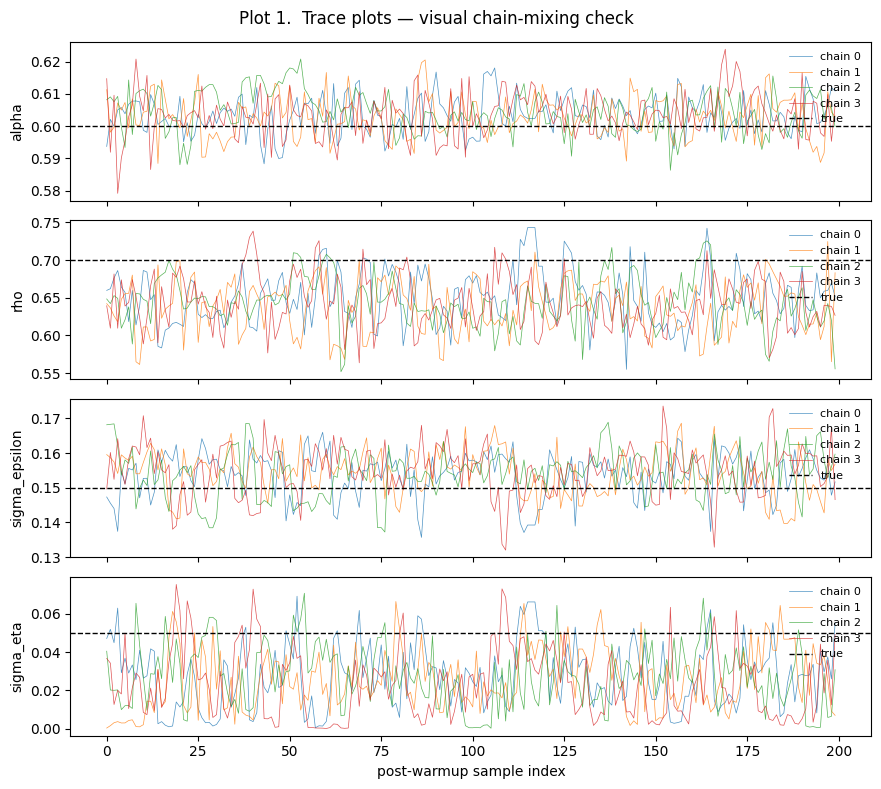

In [5]:
# Plot 1: trace plots
fig, axes = plt.subplots(len(spec.parameter_names), 1,
                         figsize=(9, 2.0 * len(spec.parameter_names)),
                         sharex=True)
for ax, k in zip(axes, spec.parameter_names):
    s = mcmc_result.posterior_samples[k]   # (n_samples, n_chains)
    for c in range(s.shape[1]):
        ax.plot(s[:, c], lw=0.5, alpha=0.8, label=f'chain {c}')
    ax.axhline(beta_true[k], color='k', lw=1.0, ls='--', label='true')
    ax.set_ylabel(k); ax.legend(loc='upper right', fontsize=8, frameon=False)
axes[-1].set_xlabel('post-warmup sample index')
plt.suptitle('Plot 1.  Trace plots — visual chain-mixing check')
plt.tight_layout()
plt.savefig(FIGURES_ROOT / 'plot1_trace.png', dpi=140, bbox_inches='tight')
plt.show()

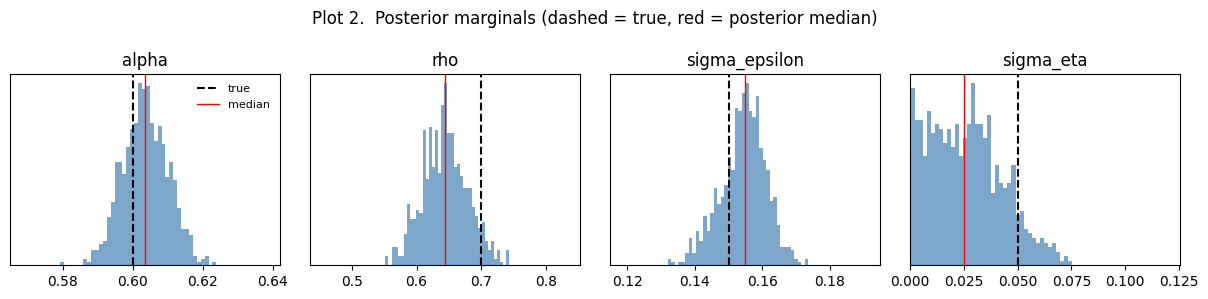

In [6]:
# Plot 2: posterior marginals.
# Fixed x-axis: ±4 posterior-sd around the median, expanded to include the
# true value if it falls outside (so a miscalibrated run stays visually
# obvious), clipped to the parameter's support. This replaces matplotlib's
# auto-scaling, which can make a tiny absolute median-vs-truth gap look
# alarming when the posterior is tight.
SUPPORT_UPPER = {'alpha': 1.0, 'rho': 1.0}  # other params are positive-unbounded

fig, axes = plt.subplots(1, len(spec.parameter_names),
                         figsize=(3.0 * len(spec.parameter_names), 3))
for ax, k in zip(axes, spec.parameter_names):
    s = mcmc_result.posterior_samples[k].reshape(-1)
    med, sd = float(np.median(s)), float(np.std(s))
    truth   = beta_true[k]
    xlo = max(0.0, min(med - 6.0 * sd, truth))
    xhi = min(SUPPORT_UPPER.get(k, np.inf), max(med + 6.0 * sd, truth))
    ax.hist(s, bins=40, alpha=0.7, density=True, color='steelblue')
    ax.axvline(truth, color='k',   lw=1.5, ls='--', label='true')
    ax.axvline(med,   color='red', lw=1.0,         label='median')
    ax.set_xlim(xlo, xhi)
    ax.set_title(k); ax.set_yticks([])
axes[0].legend(loc='upper right', fontsize=8, frameon=False)
plt.suptitle('Plot 2.  Posterior marginals (dashed = true, red = posterior median)')
plt.tight_layout()
plt.savefig(FIGURES_ROOT / 'plot2_marginals.png', dpi=140, bbox_inches='tight')
plt.show()

# Section 4: Coverage Check (Bayesian.md §2.8)

For each of `R` replicates:

1. Draw β₀ from the prior.
2. Synthesize one panel at β₀ via the analytical-policy DGP + measurement noise.
3. Run MCMC at `MCMC_COVERAGE` spec.
4. Report the 95% credible interval per parameter.

**Pass** (R=30): empirical coverage in [0.87, 1.00] per parameter, the 95% binomial interval around the target 0.95.

All seed routing matches §2.9. Tables saved to `outputs/notebooks/NB07_bayesian_validation/`. **Skipped for the FULL profile** (which is sanity-only); enabled for SMOKE (R=2 smoke test) and COVERAGE_CHECK (R=30 real validation).

In [7]:
if not RUN_COVERAGE:
    print(f'Coverage check disabled for {PROFILE} profile. '
          f'Run with PROFILE = "COVERAGE_CHECK" to validate §2.8 calibration.')
    coverage_result = None
    coverage_wall   = 0.0
else:
    t0 = time.perf_counter()
    coverage_result = run_coverage_check(
        spec, MCMC_COVERAGE, COV_CONFIG,
        master_seed=MCMC_COVERAGE.master_seed,
    )
    coverage_wall = time.perf_counter() - t0
    print(f'Coverage wall time: {coverage_wall:.1f} s '
          f'({COV_CONFIG.n_replicates} replicates, ~{coverage_wall/COV_CONFIG.n_replicates:.0f}s each)')

    # Table 2: coverage. At R=30 the 95% binomial CI around target 0.95
    # is roughly [0.87, 1.00]; we accept anything in that band as
    # consistent with calibration.
    rows = []
    for k in spec.parameter_names:
        rows.append({
            'parameter': k,
            'target':    coverage_result.credible_level,
            'empirical': coverage_result.coverage_per_parameter[k],
            'pass':      coverage_result.coverage_per_parameter[k] >= 0.87,
        })
    coverage_table = pd.DataFrame(rows)
    print('Table 2. Coverage by parameter (95% credible interval)')
    display(coverage_table)
    coverage_table.to_csv(FIGURES_ROOT / 'table2_coverage.csv', index=False)

Coverage wall time: 5839.3 s (30 replicates, ~195s each)
Table 2. Coverage by parameter (95% credible interval)


,parameter,target,empirical,pass
0,alpha,0.95,0.800000,False
1,rho,0.95,0.766667,False
2,sigma_epsilon,0.95,0.833333,False
3,sigma_eta,0.95,0.933333,True


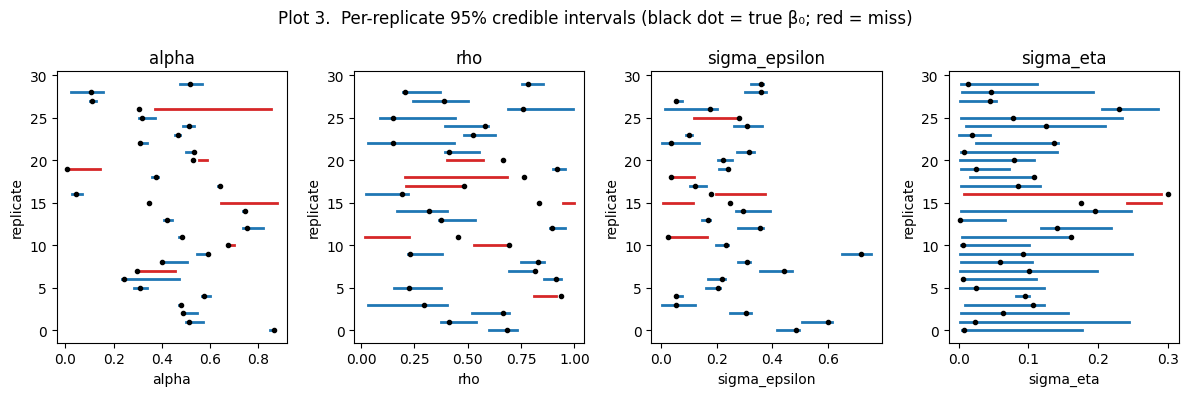

In [8]:
if not RUN_COVERAGE:
    print(f'Coverage plot skipped: no coverage results for {PROFILE} profile.')
else:
    # Plot 3: per-replicate intervals with true-value markers
    fig, axes = plt.subplots(1, len(spec.parameter_names),
                             figsize=(3.0 * len(spec.parameter_names), 4),
                             sharey=False)
    for ax, k in zip(axes, spec.parameter_names):
        R = COV_CONFIG.n_replicates
        for r in range(R):
            lo, hi = coverage_result.per_replicate_intervals[r][k]
            b0 = coverage_result.per_replicate_beta0[r][k]
            contains = lo <= b0 <= hi
            col = 'tab:blue' if contains else 'tab:red'
            ax.plot([lo, hi], [r, r], lw=2, color=col)
            ax.plot([b0], [r], 'o', color='k', markersize=3)
        ax.set_title(k); ax.set_xlabel(k); ax.set_ylabel('replicate')
    plt.suptitle('Plot 3.  Per-replicate 95% credible intervals (black dot = true β₀; '
                 'red = miss)')
    plt.tight_layout()
    plt.savefig(FIGURES_ROOT / 'plot3_coverage_intervals.png', dpi=140, bbox_inches='tight')
    plt.show()

# Section 5: Diagnostics Summary

In [9]:
if RUN_COVERAGE:
    diag_rows = []
    for r, d in enumerate(coverage_result.per_replicate_diagnostics):
        row = {'replicate': r, 'acceptance': d['acceptance_rate'],
               'wall_time_sec': d['wall_time_sec']}
        for k in spec.parameter_names:
            row[f'r_hat_{k}'] = d['r_hat'][k]
            row[f'ess_{k}']   = d['ess'][k]
        diag_rows.append(row)
    diag_table = pd.DataFrame(diag_rows)
    print('Per-replicate MCMC diagnostics (R-hat and ESS by parameter)')
    display(diag_table)
    diag_table.to_csv(FIGURES_ROOT / 'table3_diagnostics.csv', index=False)

print()
print(f'Sanity MCMC:   {sanity_wall:.1f} s')
if RUN_COVERAGE:
    print(f'Coverage runs: {coverage_wall:.1f} s ({COV_CONFIG.n_replicates} replicates)')
else:
    print(f'Coverage runs: disabled for {PROFILE} profile.')
print(f'Figures + tables saved to: {FIGURES_ROOT}')

Per-replicate MCMC diagnostics (R-hat and ESS by parameter)


,replicate,acceptance,wall_time_sec,r_hat_alpha,ess_alpha,r_hat_rho,ess_rho,r_hat_sigma_epsilon,ess_sigma_epsilon,r_hat_sigma_eta,ess_sigma_eta
0,0,0.915329,108.369503,1.007444,492.197052,1.005971,373.498474,1.000778,304.626282,1.003092,244.960587
1,1,0.954519,118.936691,1.003540,478.577209,1.028187,325.959076,1.023025,231.138214,1.064857,183.439728
2,2,0.980595,191.655368,1.001142,441.646515,1.009054,253.097107,1.033704,154.611572,1.007585,141.778168
3,3,0.939908,575.817422,1.003613,426.479431,1.002285,262.151550,1.022927,130.002045,1.025683,161.055527
4,4,0.942591,90.951303,0.996693,565.491089,1.007227,498.112030,1.006397,355.035919,1.006009,350.485840
5,5,0.848792,152.060253,1.017502,461.260620,1.047750,284.828491,1.091161,154.442322,1.095925,119.583870
6,6,0.788782,179.458743,1.021647,115.397186,1.032397,280.371033,1.023501,101.241913,1.038590,88.113846
7,7,0.876922,121.256665,1.017135,424.478119,0.997252,429.957031,1.295949,168.225143,1.175646,137.233032
8,8,0.925970,117.682380,1.002740,405.206299,1.013958,314.720520,1.036070,268.308167,1.034319,217.048126
9,9,0.905940,100.786636,1.015205,598.979126,1.009821,495.620239,1.016313,390.129700,1.045478,287.570740



Sanity MCMC:   121.3 s
Coverage runs: 5839.3 s (30 replicates)
Figures + tables saved to: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/NB07_bayesian_validation/coverage_check


# Conclusion

A successful Phase 1 validation means:

- Single-run posterior medians sit near the true β₀ for well-identified parameters. For weakly-identified parameters (e.g., σ_η, §2.3), the single-run posterior may miss the truth in any individual run while remaining calibrated *on average* across replicates. The coverage check is the calibration test, not the single run.
- R-hat < 1.01 (FULL spec) or < 1.05 at smaller specs.
- ESS > 200 for every parameter at FULL settings; > 50 per replicate at COVERAGE_CHECK.
- Empirical coverage at 95% credible level inside [0.87, 1.00] for every parameter at R=30 (COVERAGE_CHECK profile).

Phase 2 swaps the model-solve (analytical → NN-amortized) and reuses `run_mcmc` / `run_coverage_check` unchanged via a sibling factory in `src/v2/estimation/`. Phase 3 (risky debt) adds a particle-filter `make_bayesian_spec` returning `filter_kind=PARTICLE, sampler_kind=RW_MH` (PMMH) and the same runners produce the validation.